# Visualize Paris region

In [1]:
%load_ext autoreload
%autoreload 2
%cd D:\netmob25

D:\netmob25


In [8]:
import os
os.environ['USE_PYGEOS'] = '0'
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import zipfile
import io
from shapely.geometry import LineString
from pathlib import Path
from tqdm import tqdm

## 1. Layer 1 - Paris IRIS

<Axes: >

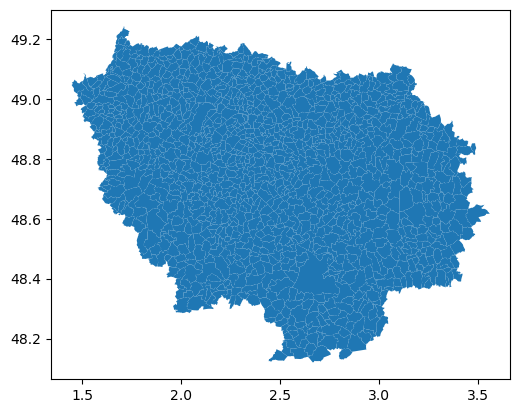

In [13]:
gdf = gpd.read_file('dbs/geo/paris_iris.geojson')
gdf = gdf.dissolve(by="insee_com")
gdf.plot()

In [14]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## 2. Layer 2 - Home and work locations

In [21]:
# Purchase
df_work = pd.read_csv('dbs/data_p/commuter_trips.csv')
df_work = df_work[['ID', 'purpose_o', 'start_lat', 'start_lon']]
df_work = df_work[df_work['purpose_o'].isin(['HOME', 'WORK', 'STUDIES'])].drop_duplicates(subset=['ID', 'purpose_o'])

In [27]:
df_locs = pd.concat([df_work[df_work['purpose_o'] == 'HOME'].rename(columns={'start_lat': 'lat', 'start_lon': 'lon'}).assign(Location='Home'),
                     df_work[df_work['purpose_o'].isin(['WORK', 'STUDIES'])].rename(columns={'start_lat': 'lat', 'start_lon': 'lon'}).assign(Location='Work/Study')], ignore_index=True)
df_locs.drop(columns=['purpose_o'], inplace=True)
df_locs.to_csv('dbs/geo/paris_locs.csv', index=False)

## 3. Layer 3 - Public transit network

In [3]:
# -------- 1) Load GTFS tables from the .zip --------
gtfs_zip = Path("dbs/accessibility/data/IDFM-gtfs.zip")

with zipfile.ZipFile(gtfs_zip) as z:
    routes = pd.read_csv(io.BytesIO(z.read("routes.txt")))
    trips = pd.read_csv(io.BytesIO(z.read("trips.txt")))
    stop_times = pd.read_csv(io.BytesIO(z.read("stop_times.txt")))
    stops = pd.read_csv(io.BytesIO(z.read("stops.txt")))

# Merge stop_times with stops for coordinates
stop_times = stop_times.merge(stops[["stop_id", "stop_lat", "stop_lon"]],
                                on="stop_id", how="left")
stop_times = stop_times.sort_values(["trip_id", "stop_sequence"])

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_15896\223238127.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  trips = pd.read_csv(io.BytesIO(z.read("trips.txt")))
C:\Users\yuanlia\AppData\Local\Temp\ipykernel_15896\223238127.py:7: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(io.BytesIO(z.read("stop_times.txt")))


In [9]:
# For each trip, make a LineString of stops
tqdm.pandas()
trip_lines = (
    stop_times.groupby("trip_id")[["stop_lon", "stop_lat"]]
    .progress_apply(lambda df: LineString(df.to_numpy()))
    .reset_index(name="geometry")
)

100%|██████████| 479548/479548 [00:16<00:00, 29482.74it/s]


In [10]:
gdf_trips = gpd.GeoDataFrame(trip_lines, geometry="geometry", crs="EPSG:4326")

print('Attach routes')
gdf_routes = gdf_trips.merge(trips[["trip_id","route_id"]], on="trip_id", how="left") \
                        .merge(routes, on="route_id", how="left")

print('Collapse: 1 line per route by taking union of trip lines')
gdf_routes = gdf_routes.dissolve(by="route_id", as_index=False)

Attach routes
Collapse: 1 line per route by taking union of trip lines


C:\Users\yuanlia\AppData\Local\Temp\ipykernel_15896\3333237622.py:10: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  gpd.GeoSeries().plot(ax=ax)  # no basemap here; add your background tiles if you like


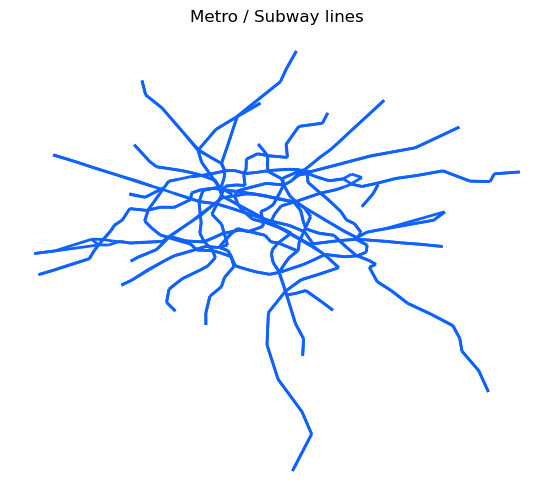

In [11]:
# -------- 4) Filter by mode (e.g., Metro/Subway) --------
gdf_metro = gdf_routes[gdf_routes["route_type"] == 1]      # metro/subway
gdf_tram  = gdf_routes[gdf_routes["route_type"] == 0]      # tram/light rail
gdf_rail  = gdf_routes[gdf_routes["route_type"] == 2]      # commuter/intercity rail
gdf_bus   = gdf_routes[gdf_routes["route_type"] == 3]      # bus
# etc.

# -------- 5) Quick plot (optional) --------
ax = gdf_metro.plot(figsize=(8, 6), linewidth=2, color="#0F62FE")
gpd.GeoSeries().plot(ax=ax)  # no basemap here; add your background tiles if you like
ax.set_title("Metro / Subway lines")
ax.set_axis_off()

# -------- 6) Export for GIS / web --------
# a) GeoPackage with separate layers per mode
out_gpkg = Path("dbs/geo/gtfs_routes.gpkg")
if out_gpkg.exists():
    out_gpkg.unlink()  # overwrite cleanly

gdf_routes.to_file(out_gpkg, layer="all_routes", driver="GPKG")
gdf_metro.to_file(out_gpkg, layer="metro", driver="GPKG")
gdf_tram.to_file(out_gpkg, layer="tram", driver="GPKG")
gdf_rail.to_file(out_gpkg, layer="rail", driver="GPKG")
gdf_bus.to_file(out_gpkg, layer="bus", driver="GPKG")

C:\Users\yuanlia\AppData\Local\Temp\ipykernel_15896\480685488.py:3: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  gpd.GeoSeries().plot(ax=ax)  # no basemap here; add your background tiles if you like


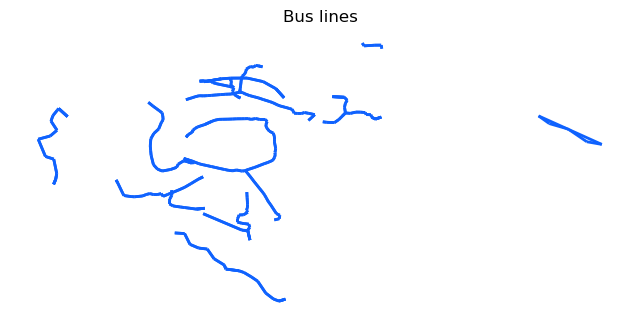

In [17]:
# -------- 5) Quick plot (optional) --------
ax = gdf_tram.plot(figsize=(8, 6), linewidth=2, color="#0F62FE")
gpd.GeoSeries().plot(ax=ax)  # no basemap here; add your background tiles if you like
ax.set_title("Bus lines")
ax.set_axis_off()